In [1]:
#import libraries
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import spacy
import sys
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
import string
import warnings
warnings.filterwarnings('ignore')

nltk.download('wordnet')
nltk.download('omw-1.4')


nltk.download('stopwords')

!python -m spacy download en_core_web_sm
!python -m spacy download xx_ent_wiki_sm

#setting configuration for all our plots
sns.set_style('darkgrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (8,5)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 116.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 69.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('xx_ent_wiki_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
!pip install langid

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 43.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langid: filename=langid-1.1.6-py3-none-any.whl size=1941171 sha256=1fa8dc9dc14028d27e759a3fee51a5118cf056e578c364d1b8b8ebf72ca6dad1
  Stored in directory: /root/.cache/pip/wheels/3c/bc/9d/266e27289b9019680d65d9b608c37bff1eff565b001c977ec5
Successfully built langid


In [3]:
#from google.colab import files
#uploaded = files.upload()

In [4]:
data_path = Path("/content/drive/MyDrive/raw_reviews.csv")
df = pd.read_csv(data_path)
df.head()

,review_id,product_category,timestamp,country,rating,review,sentiment
0,1,Books,2023-01-01,GB,3,"Solid build, attractive design, works as adver...",positive
1,2,Toys,2023-01-01,DE,5,Ich liebe dieses Produkt! ⭐⭐⭐,positive
2,3,Beauty,2023-01-01,AU,3,Three stars — meets THE minimum expectations.,neutral
3,4,Toys,2023-01-01,US,5,"Solid build, attractive design, works as adver...",positive
4,5,Electronics,2023-01-01,CA,2,Broken on arrival. Return process was a NIGHTM...,negative


In [5]:
#df = pd.read_csv("raw_reviews.csv")
#df.head()

In [6]:
sample_df = df.sample(n=100, random_state=42)
sample_df.head()
sample_df.to_csv("/content/drive/MyDrive/sample_reviews.csv", index=False)

In [7]:
df.shape

(120000, 7)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isna().sum()

,0
review_id,0
product_category,0
timestamp,0
country,0
rating,0
review,0
sentiment,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   review_id         120000 non-null  int64 
 1   product_category  120000 non-null  object
 2   timestamp         120000 non-null  object
 3   country           120000 non-null  object
 4   rating            120000 non-null  int64 
 5   review            120000 non-null  object
 6   sentiment         120000 non-null  object
dtypes: int64(2), object(5)
memory usage: 6.4+ MB


In [11]:
df.columns

Index(['review_id', 'product_category', 'timestamp', 'country', 'rating',
       'review', 'sentiment'],
      dtype='object')

EXPLORATORY DATA ANALYSIS

In [12]:
df.product_category.value_counts().reset_index()

,product_category,count
0,Sports,15097
1,Electronics,15052
2,Toys,15049
3,Home & Living,15047
4,Books,15037
5,Beauty,15019
6,Fashion,14993
7,Food & Grocery,14706


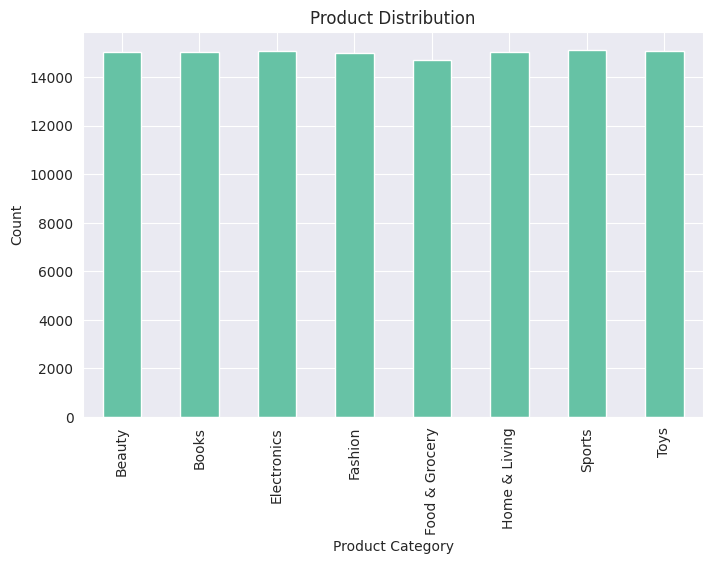

In [13]:
df['product_category'].value_counts().sort_index().plot(kind='bar', title='Product Distribution')
plt.xlabel('Product Category')
plt.ylabel('Count')
plt.show()

From the plot we can see that Product categories are evenly distributed (no major imbalance).
Ensures fair comparison across categories in analysis.

Rating Distribution per product category

In [14]:
#plot of rating per product_category
df.groupby('product_category')['rating'].count().reset_index()

,product_category,rating
0,Beauty,15019
1,Books,15037
2,Electronics,15052
3,Fashion,14993
4,Food & Grocery,14706
5,Home & Living,15047
6,Sports,15097
7,Toys,15049


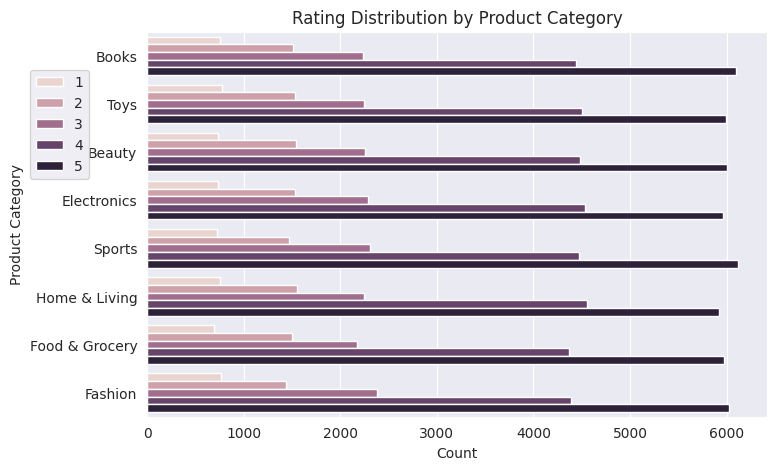

In [15]:
# Rating Distribution by Product Category
sns.countplot(y='product_category', hue='rating', data=df)
plt.title('Rating Distribution by Product Category')
plt.xlabel('Count')
plt.ylabel('Product Category')
plt.legend(loc='lower left', bbox_to_anchor=(-0.2, 0.6))
plt.show()

This plot shows that all categories show a similar pattern:
High 5-star dominance followed by 4-star ratings. No category shows unusually poor ratings.

In [16]:
df.groupby('product_category')['sentiment'].count().reset_index()

,product_category,sentiment
0,Beauty,15019
1,Books,15037
2,Electronics,15052
3,Fashion,14993
4,Food & Grocery,14706
5,Home & Living,15047
6,Sports,15097
7,Toys,15049


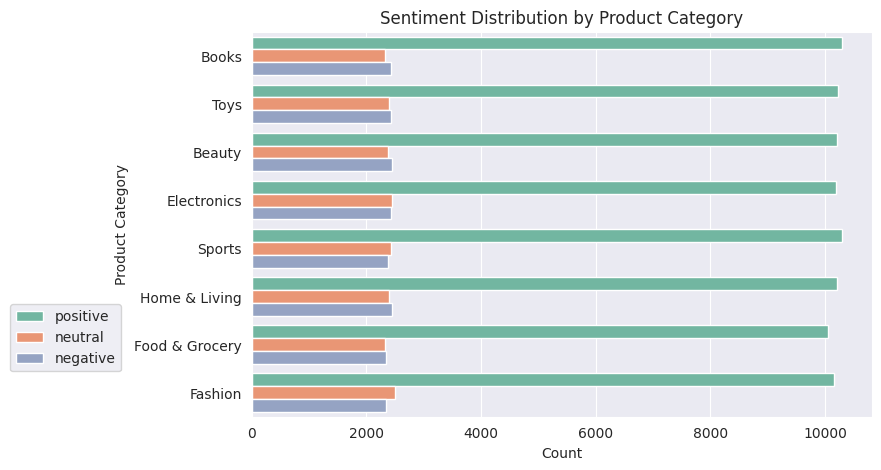

In [17]:
# Sentiment Distribution by Product Category
sns.countplot(y='product_category', hue='sentiment', data=df)
plt.title('Sentiment Distribution by Product Category')
plt.xlabel('Count')
plt.ylabel('Product Category')
plt.legend(loc='lower right', bbox_to_anchor=(-0.2, 0.1))
plt.show()

This plot shows that categories are dominated by positive sentiment.
Slight variations exist, but no category stands out as highly negative.


Do “positive” reviews actually have high ratings?

In [18]:
#Average rating per sentiment (per category)
df.groupby(['product_category', 'sentiment'])['rating'].mean().reset_index()

,product_category,sentiment,rating
0,Beauty,negative,1.946895
1,Beauty,neutral,3.096543
2,Beauty,positive,4.551329
3,Books,negative,1.910744
4,Books,neutral,3.076359
5,Books,positive,4.560734
6,Electronics,negative,1.909542
7,Electronics,neutral,3.107975
8,Electronics,positive,4.555272
9,Fashion,negative,1.894625


Do customers rate products consistently with their written sentiment?

In [19]:
#Checking for mismatch records of product ratings and sentiment
mismatch = df[
    ((df['rating'] >= 4) & (df['sentiment'] == 'negative')) |
    ((df['rating'] <= 2) & (df['sentiment'] == 'positive'))
]
mismatch.head()

,review_id,product_category,timestamp,country,rating,review,sentiment
80,81,Sports,2023-01-01,GB,1,Perfect gift idea. Delivery was speedy and pac...,positive
127,128,Beauty,2023-01-02,GB,4,Waste of money. Don't buy this product.,negative
204,205,Electronics,2023-01-02,GB,2,Exactly WHAT I was looking for. Great price.,positive
349,350,Books,2023-01-04,DE,4,Absoluter Betrug! Produkt nie erhalten. Finger...,negative
380,381,Home & Living,2023-01-04,ES,5,Muy decepcionado. El producto llegó roto y el ...,negative


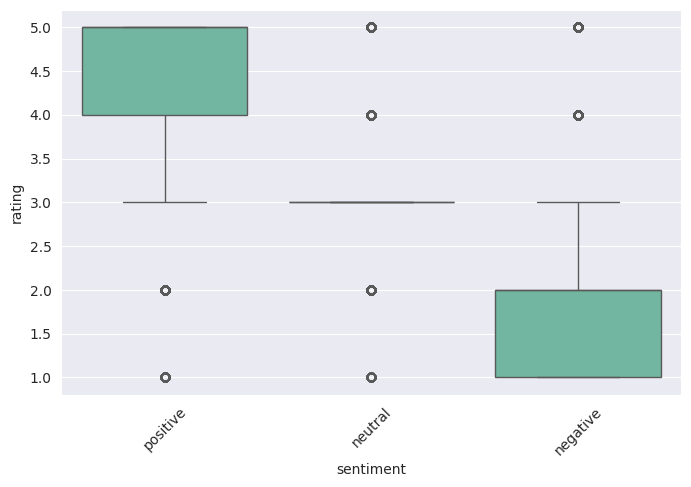

In [20]:
#Checking for inconsitencies in rating and sentiment
sns.boxplot(data=df, x='sentiment', y='rating')
plt.xticks(rotation=45)
plt.show()

Across product categories, sentiment labels generally align with customer ratings, with positive reviews showing higher average ratings. However, certain categories exhibit inconsistencies, where negative sentiment appears alongside high ratings. This suggests either customer experience nuances or potential misclassification in sentiment labeling, highlighting areas for further investigation.


Rating Distributing

In [21]:
# checking for rating distribution to know the emotions of our customers
df['rating'].value_counts().reset_index()

,rating,count
0,5,48091
1,4,35754
2,3,18143
3,2,12080
4,1,5932


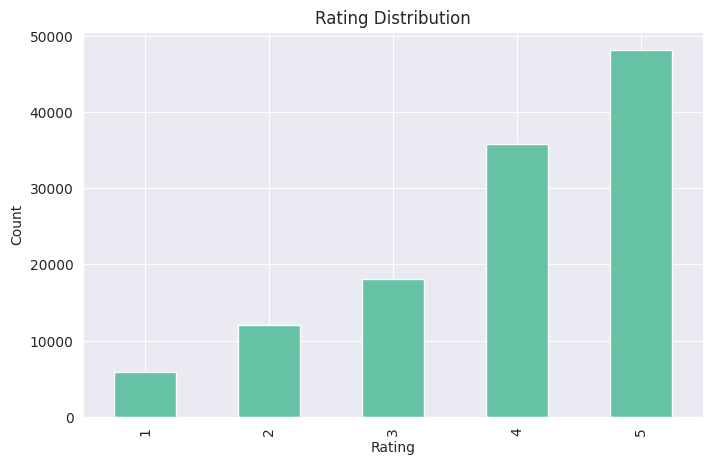

In [22]:
df['rating'].value_counts().sort_index().plot(kind='bar', title='Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

The plot is clearly skewwed toward higher ratings (4 and 5 stars).
5-star ratings are the most frequent, followed by 4-star.
Very few low ratings

Reviews by Country

In [23]:
df['country'].value_counts().reset_index()

,country,count
0,GB,21106
1,US,21057
2,DE,18905
3,FR,16500
4,ES,9356
5,AU,4779
6,MX,4706
7,CA,4651
8,AT,4620
9,CH,3622


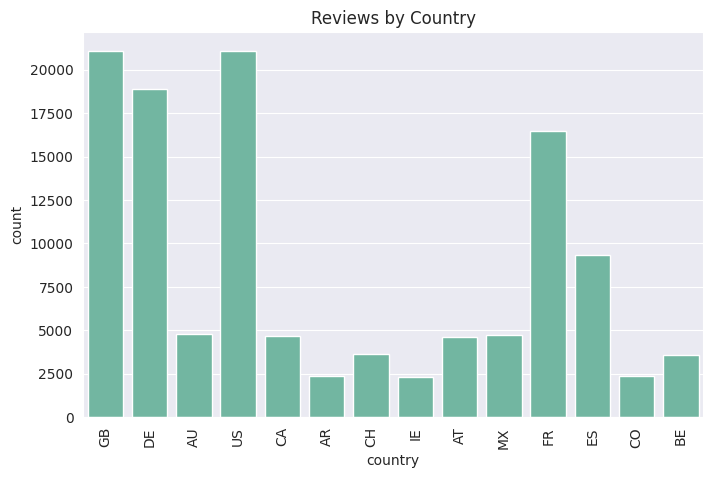

In [24]:
# Checking the country with the highest review
sns.countplot(x='country', data=df)
plt.xticks(rotation=90)
plt.title('Reviews by Country')
plt.show()

Highest activity comes from US, GB, and DE.
Other countries contribute smaller but consistent volumes.


Sentiment Distribution per Country

In [25]:
df['sentiment'].value_counts().reset_index()

,sentiment,count
0,positive,81591
1,negative,19233
2,neutral,19176


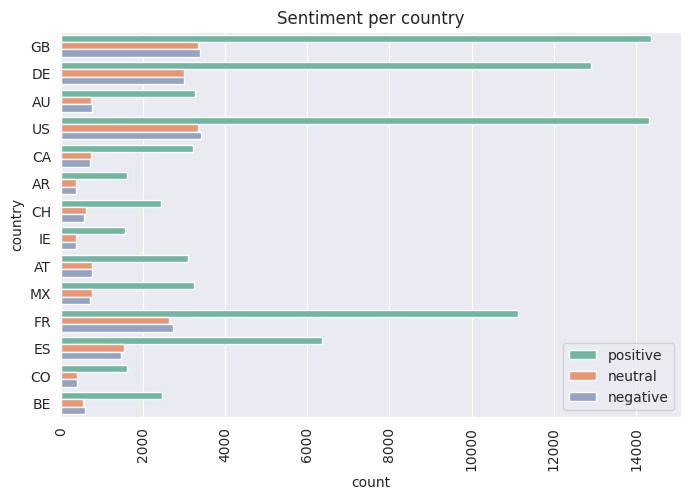

In [26]:
# Checking the country with the highest Sentiment count
sns.countplot(y='country', hue = 'sentiment', data=df)
plt.xticks(rotation=90)
plt.title('Sentiment per country')
plt.legend()
plt.show()

Positive sentiment dominates across all countries.
US, GB, and DE again lead in volume of positive reviews.
Neutral and negative sentiments are significantly lower, showing consistency with high ratings.

Rating Distribution per country

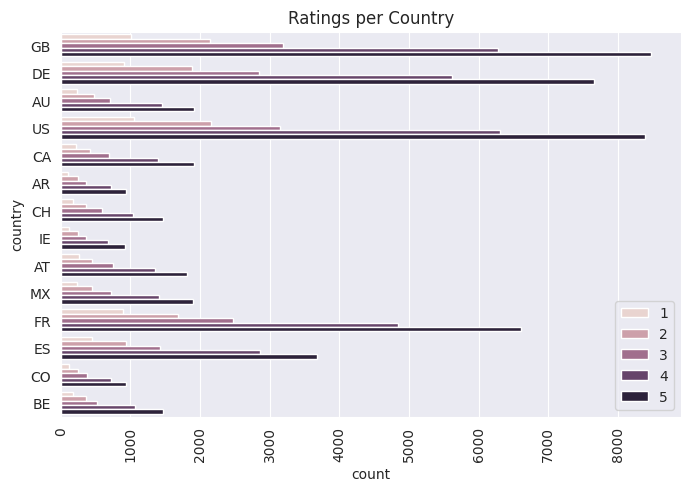

In [27]:
# Checking the country with the highest Rating count
sns.countplot(y='country', hue = 'rating', data=df)
plt.xticks(rotation=90)
plt.title('Ratings per Country')
plt.legend()
plt.show()

Most countries show a strong dominance of 4 and 5-star ratings.
US, GB, and DE have the highest review volumes and highest 5-star counts.
Lower ratings (1–2 stars) are relatively rare across all countries.
Suggesting generally high customer satisfaction globally.

Spotting the Noise
The noise in the review column includes emoji, uppercase, symbols etc

In [28]:
def has_numbers(text):
    return bool(re.search(r'\d', str(text)))

def has_emoji(text):
    return bool(re.search(r'[\U00010000-\U0010ffff]', str(text)))

def is_uppercase(text):
    return str(text).isupper()

def has_symbols(text):
    return bool(re.search(r'[^\w\s]', str(text)))  # punctuation/symbols

def has_multilingual(text):
    # Detect non-English characters (basic approach)
    return bool(re.search(r'[^\x00-\x7F]', str(text)))

In [29]:
def sample_reviews(df, condition_func, n=5):
    subset = df[df['review'].apply(condition_func)]
    return subset['review'].sample(min(n, len(subset)), random_state=42)

In [30]:
print("Reviews with numbers:")
print(sample_reviews(df, has_numbers), "\n")

print("Reviews with emojis:")
print(sample_reviews(df, has_emoji), "\n")

print("Uppercase reviews:")
print(sample_reviews(df, is_uppercase), "\n")

print("Reviews with symbols/punctuation:")
print(sample_reviews(df, has_symbols), "\n")

print("Multilingual reviews:")
print(sample_reviews(df, has_multilingual), "\n")

Reviews with numbers:
41453     Shipping took three weeks and the item was DAM...
110812    Shipping took three WEEKS and the item was dam...
4698      Shipping took three weeks and the item was dam...
105542    Shipping took three weeks and the item was dam...
38731     Délai de livraison excessif et produit endomma...
Name: review, dtype: object 

Reviews with emojis:
14447          Top-notch quality, exactly what I needed. 👍
23018    Solid build, attractive design, works as adver...
41635    Ausgezeichnetes Produkt. Übertrifft alle meine...
18226    Very pleased with this purchase. Quick deliver...
46262    Perfect gift idea. Delivery was speedy and pac...
Name: review, dtype: object 

Uppercase reviews:
Series([], Name: review, dtype: object) 

Reviews with symbols/punctuation:
71787    Excellent rapport qualité-prix. Très satisfait...
67218    Muy buena relación calidad-precio. Repetiré la...
54066          Brilliant product, can't fault it at ALL. 👍
7168                Wunderbar!

Exploratory text analysis revealed the presence of noise such as emojis, multilingual content, numeric-heavy reviews, and excessive punctuation. These patterns informed preprocessing decisions including text normalization, token cleaning, and potential language filtering to improve model performance.

DATA CLEANING

In [31]:
#Fix date type
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

In [32]:
#checking for dataset info again
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   review_id         120000 non-null  int64         
 1   product_category  120000 non-null  object        
 2   timestamp         120000 non-null  datetime64[ns]
 3   country           120000 non-null  object        
 4   rating            120000 non-null  int64         
 5   review            120000 non-null  object        
 6   sentiment         120000 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(4)
memory usage: 6.4+ MB


In [33]:
#Standardize text (Review column)
df['review'] = df['review'].str.lower()  # lowercase
df['review'] = df['review'].str.strip()  # remove spaces

In [34]:
#Removing noise from text

def clean_text(text):
    text = re.sub(r'http\S+', '', text)              # remove URLs
    text = re.sub(r'@\w+', '', text)                 # remove mentions
    text = re.sub(r'\d+', '', text)                  # Remove numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)          # remove symbols
    text = re.sub(r'[\U00010000-\U0010ffff]', '', text)  # remove emojis
    text = re.sub(r'[^\w\s]', '', text)               # remove punctuation
    return text

df['clean_review'] = df['review'].apply(clean_text)

In [35]:
#remove extra white space
df['clean_review'] = df['clean_review'].apply(
    lambda x: re.sub(r'\s+', ' ', str(x)).strip()
)

In [36]:
df[['review', 'clean_review']].sample(10)

,review,clean_review
63822,excellent quality and fast shipping. will defi...,excellent quality and fast shipping will defin...
106404,no vale lo que cuesta. completa pérdida de din...,no vale lo que cuesta completa prdida de dinero
53181,"moyen. le produit fait ce qu'il doit faire, ni...",moyen le produit fait ce quil doit faire ni pl...
48634,très content de mon achat. le produit est enco...,trs content de mon achat le produit est encore...
55506,très mauvaise expérience. je demande un rembou...,trs mauvaise exprience je demande un rembourse...
13356,ni bien ni mal. hace lo que se supone que debe...,ni bien ni mal hace lo que se supone que debe ...
12536,very pleased with this purchase. quick deliver...,very pleased with this purchase quick delivery...
58561,sehr enttäuscht. das produkt ist kaputt angeko...,sehr enttuscht das produkt ist kaputt angekommen
50346,produit de très bonne qualité. je recommande s...,produit de trs bonne qualit je recommande sans...
23782,product arrived quickly and looks exactly as d...,product arrived quickly and looks exactly as d...


In [37]:
# functions to check individual rows for messiness
def has_emoji(text):
    return bool(re.search(r'[\U00010000-\U0010ffff]', str(text)))

def has_numbers(text):
    return bool(re.search(r'\d', str(text)))

def has_uppercase(text):
    return any(char.isupper() for char in str(text))

def has_extra_whitespace(text):
    return bool(re.search(r'\s{2,}', str(text)))

def has_punctuation(text):
    return bool(re.search(r'[^\w\s]', str(text)))

In [38]:
#checking if rows have been properly cleaned
emoji_count = df['clean_review'].apply(has_emoji).sum()
number_count = df['clean_review'].apply(has_numbers).sum()
uppercase_count = df['clean_review'].apply(has_uppercase).sum()
whitespace_count = df['clean_review'].apply(has_extra_whitespace).sum()
punctuation_count = df['clean_review'].apply(has_punctuation).sum()

print("Emoji rows:", emoji_count)
print("Number rows:", number_count)
print("Uppercase rows:", uppercase_count)
print("Whitespace rows:", whitespace_count)
print("Punctuation rows:", punctuation_count)

Emoji rows: 0
Number rows: 0
Uppercase rows: 0
Whitespace rows: 0
Punctuation rows: 0


In [39]:
#Reviewing processed data (clean_review) after cleaning
df['clean_review'].head(10)

,clean_review
0,solid build attractive design works as adverti...
1,ich liebe dieses produkt
2,three stars meets the minimum expectations
3,solid build attractive design works as adverti...
4,broken on arrival return process was a nightmare
5,terrible servicio al cliente jams volvera a co...
6,solide aber unremarkabel wrde ich nicht unbedi...
7,superb quality very sturdy and wellmade five s...
8,cest correct pour le prix lol
9,really impressed with the build quality would ...


During the data cleaning stage, I converted text to lowercase.
Removed punctuation, numbers, emojis, special characters and extra whitespace

The purpose of the data cleaning is to standardize text format, reduce noise that does not contribute to sentiment meaning and ensure consistent input for NLP models

The impact of the data cleaning is to eliminated irrelevant characters that could confuse the model, improved token consistency (e.g., “Good”, “good”, “GOOD” → “good”) and reduced feature dimensionality during vectorization

Lemmatization

In [40]:
import langid

def possibly_multilingual(text):
    return bool(re.search(r'[^\x00-\x7F]', str(text)))

def detect_language_fast(text):
    try:
        return langid.classify(str(text)[:200])[0]
    except:
        return "unknown"

df['language'] = 'en'
mask = df['review'].apply(possibly_multilingual)
df.loc[mask, 'language'] = df.loc[mask, 'review'].apply(detect_language_fast)

To reduce computational cost and time, I used a faster language detection (langid) which was applied selectively (only on the first 200 characters) to reviews likely to contain non-English content, while English was assumed as the default for the remaining reviews.

In [41]:
#checks for all the language used in the review
df['language'].unique()

array(['en', 'de', 'es', 'fr', 'an', 'gl', 'cs', 'la', 'hu'], dtype=object)

In [42]:
#checks for the column in the dataset
print(df.columns)

Index(['review_id', 'product_category', 'timestamp', 'country', 'rating',
       'review', 'sentiment', 'clean_review', 'language'],
      dtype='object')


In [43]:
#lemmatize text function
nlp_en = spacy.load("en_core_web_sm", disable=["parser", "ner", "textcat"])
nlp_multi = spacy.load("xx_ent_wiki_sm", disable=["parser", "ner", "textcat"])

def lemmatize_multilingual(text, lang):
    text = str(text)

    if lang == 'en':
        doc = nlp_en(text)
    else:
        doc = nlp_multi(text)

    tokens = [token.lemma_ if token.lemma_ else token.text for token in doc]
    return " ".join(tokens).strip()

df['lemma_text_review'] = df.apply(
    lambda row: lemmatize_multilingual(row['clean_review'], row['language']),
    axis=1
)
df.head(10)

,review_id,product_category,timestamp,country,rating,review,sentiment,clean_review,language,lemma_text_review
0,1,Books,2023-01-01,GB,3,"solid build, attractive design, works as adver...",positive,solid build attractive design works as adverti...,en,solid build attractive design work as advertis...
1,2,Toys,2023-01-01,DE,5,ich liebe dieses produkt! ⭐⭐⭐,positive,ich liebe dieses produkt,de,ich liebe dieses produkt
2,3,Beauty,2023-01-01,AU,3,three stars — meets the minimum expectations.,neutral,three stars meets the minimum expectations,en,three star meet the minimum expectation
3,4,Toys,2023-01-01,US,5,"solid build, attractive design, works as adver...",positive,solid build attractive design works as adverti...,en,solid build attractive design work as advertis...
4,5,Electronics,2023-01-01,CA,2,broken on arrival. return process was a nightm...,negative,broken on arrival return process was a nightmare,en,break on arrival return process be a nightmare
5,6,Sports,2023-01-01,AR,2,terrible servicio al cliente. jamás volvería a...,negative,terrible servicio al cliente jams volvera a co...,es,terrible servicio al cliente jams volvera a co...
6,7,Home & Living,2023-01-01,DE,3,"solide, aber unremarkabel. würde ich nicht unb...",neutral,solide aber unremarkabel wrde ich nicht unbedi...,de,solide aber unremarkabel wrde ich nicht unbedi...
7,8,Beauty,2023-01-01,GB,4,"superb quality, very sturdy and well-made. fiv...",positive,superb quality very sturdy and wellmade five s...,en,superb quality very sturdy and wellmade five star
8,9,Food & Grocery,2023-01-01,CH,3,c'est correct pour le prix. lol 👍,neutral,cest correct pour le prix lol,fr,cest correct pour le prix lol
9,10,Food & Grocery,2023-01-01,AU,4,really impressed with the build quality. would...,positive,really impressed with the build quality would ...,en,really impress with the build quality would bu...


Lemmatization was used to reduce words to their base/root form(lemma).
Applied primarily to English and multilingual reviews using spaCy.

The purpose is to normalize word variations and ensure similar words are treated as the same feature

Lemmatization helped to reduce vocabulary size, improve generalization of the model and helped group similar meanings.


In [44]:
# check for column after lemmatization
df.columns

Index(['review_id', 'product_category', 'timestamp', 'country', 'rating',
       'review', 'sentiment', 'clean_review', 'language', 'lemma_text_review'],
      dtype='object')

Removal of stopwords

In [45]:
stop_words = set(stopwords.words('english'))

df['final_review'] = df['lemma_text_review'].apply(
    lambda x: ' '.join([word for word in x.split() if word not in stop_words])
)
df.head(10)

,review_id,product_category,timestamp,country,rating,review,sentiment,clean_review,language,lemma_text_review,final_review
0,1,Books,2023-01-01,GB,3,"solid build, attractive design, works as adver...",positive,solid build attractive design works as adverti...,en,solid build attractive design work as advertis...,solid build attractive design work advertise love
1,2,Toys,2023-01-01,DE,5,ich liebe dieses produkt! ⭐⭐⭐,positive,ich liebe dieses produkt,de,ich liebe dieses produkt,ich liebe dieses produkt
2,3,Beauty,2023-01-01,AU,3,three stars — meets the minimum expectations.,neutral,three stars meets the minimum expectations,en,three star meet the minimum expectation,three star meet minimum expectation
3,4,Toys,2023-01-01,US,5,"solid build, attractive design, works as adver...",positive,solid build attractive design works as adverti...,en,solid build attractive design work as advertis...,solid build attractive design work advertise love
4,5,Electronics,2023-01-01,CA,2,broken on arrival. return process was a nightm...,negative,broken on arrival return process was a nightmare,en,break on arrival return process be a nightmare,break arrival return process nightmare
5,6,Sports,2023-01-01,AR,2,terrible servicio al cliente. jamás volvería a...,negative,terrible servicio al cliente jams volvera a co...,es,terrible servicio al cliente jams volvera a co...,terrible servicio al cliente jams volvera comp...
6,7,Home & Living,2023-01-01,DE,3,"solide, aber unremarkabel. würde ich nicht unb...",neutral,solide aber unremarkabel wrde ich nicht unbedi...,de,solide aber unremarkabel wrde ich nicht unbedi...,solide aber unremarkabel wrde ich nicht unbedi...
7,8,Beauty,2023-01-01,GB,4,"superb quality, very sturdy and well-made. fiv...",positive,superb quality very sturdy and wellmade five s...,en,superb quality very sturdy and wellmade five star,superb quality sturdy wellmade five star
8,9,Food & Grocery,2023-01-01,CH,3,c'est correct pour le prix. lol 👍,neutral,cest correct pour le prix lol,fr,cest correct pour le prix lol,cest correct pour le prix lol
9,10,Food & Grocery,2023-01-01,AU,4,really impressed with the build quality. would...,positive,really impressed with the build quality would ...,en,really impress with the build quality would bu...,really impress build quality would buy


Stop word removal helped to remove common words by applying language-specific stopword filtering.

The purpose is to remove non-informative words, focus on words that carry sentiment meaning.

The impact of this to the dataset is to reduce noise in text representation, improve model efficiency and performance.


In [46]:
#creating label column to group rating into 0 for (1,2), 1 for (3) and 2 for (4,5)
df['label'] = df['rating'].apply(lambda r: 0 if r in (1,2) else ( 1 if r == 3 else 2))
df.head()

,review_id,product_category,timestamp,country,rating,review,sentiment,clean_review,language,lemma_text_review,final_review,label
0,1,Books,2023-01-01,GB,3,"solid build, attractive design, works as adver...",positive,solid build attractive design works as adverti...,en,solid build attractive design work as advertis...,solid build attractive design work advertise love,1
1,2,Toys,2023-01-01,DE,5,ich liebe dieses produkt! ⭐⭐⭐,positive,ich liebe dieses produkt,de,ich liebe dieses produkt,ich liebe dieses produkt,2
2,3,Beauty,2023-01-01,AU,3,three stars — meets the minimum expectations.,neutral,three stars meets the minimum expectations,en,three star meet the minimum expectation,three star meet minimum expectation,1
3,4,Toys,2023-01-01,US,5,"solid build, attractive design, works as adver...",positive,solid build attractive design works as adverti...,en,solid build attractive design work as advertis...,solid build attractive design work advertise love,2
4,5,Electronics,2023-01-01,CA,2,broken on arrival. return process was a nightm...,negative,broken on arrival return process was a nightmare,en,break on arrival return process be a nightmare,break arrival return process nightmare,0


In [47]:
# Save the df as clean csv
df.to_csv("/content/drive/MyDrive/clean_review.csv", index=False)

In [48]:
#Review all derived columns and their processed data
df[['review', 'clean_review', 'lemma_text_review', 'final_review']].head(10)

,review,clean_review,lemma_text_review,final_review
0,"solid build, attractive design, works as adver...",solid build attractive design works as adverti...,solid build attractive design work as advertis...,solid build attractive design work advertise love
1,ich liebe dieses produkt! ⭐⭐⭐,ich liebe dieses produkt,ich liebe dieses produkt,ich liebe dieses produkt
2,three stars — meets the minimum expectations.,three stars meets the minimum expectations,three star meet the minimum expectation,three star meet minimum expectation
3,"solid build, attractive design, works as adver...",solid build attractive design works as adverti...,solid build attractive design work as advertis...,solid build attractive design work advertise love
4,broken on arrival. return process was a nightm...,broken on arrival return process was a nightmare,break on arrival return process be a nightmare,break arrival return process nightmare
5,terrible servicio al cliente. jamás volvería a...,terrible servicio al cliente jams volvera a co...,terrible servicio al cliente jams volvera a co...,terrible servicio al cliente jams volvera comp...
6,"solide, aber unremarkabel. würde ich nicht unb...",solide aber unremarkabel wrde ich nicht unbedi...,solide aber unremarkabel wrde ich nicht unbedi...,solide aber unremarkabel wrde ich nicht unbedi...
7,"superb quality, very sturdy and well-made. fiv...",superb quality very sturdy and wellmade five s...,superb quality very sturdy and wellmade five star,superb quality sturdy wellmade five star
8,c'est correct pour le prix. lol 👍,cest correct pour le prix lol,cest correct pour le prix lol,cest correct pour le prix lol
9,really impressed with the build quality. would...,really impressed with the build quality would ...,really impress with the build quality would bu...,really impress build quality would buy


After preprocessing, the dataset shows no presence of emojis, numbers, uppercase inconsistencies, or punctuation noise. Remaining whitespace reflects normal word separation rather than data quality issues. Additional checks confirmed minimal presence of excessive or irregular spacing.”

BASELINE MODELING

In [49]:
sentiment_data = df.copy()
sentiment_data.head()

,review_id,product_category,timestamp,country,rating,review,sentiment,clean_review,language,lemma_text_review,final_review,label
0,1,Books,2023-01-01,GB,3,"solid build, attractive design, works as adver...",positive,solid build attractive design works as adverti...,en,solid build attractive design work as advertis...,solid build attractive design work advertise love,1
1,2,Toys,2023-01-01,DE,5,ich liebe dieses produkt! ⭐⭐⭐,positive,ich liebe dieses produkt,de,ich liebe dieses produkt,ich liebe dieses produkt,2
2,3,Beauty,2023-01-01,AU,3,three stars — meets the minimum expectations.,neutral,three stars meets the minimum expectations,en,three star meet the minimum expectation,three star meet minimum expectation,1
3,4,Toys,2023-01-01,US,5,"solid build, attractive design, works as adver...",positive,solid build attractive design works as adverti...,en,solid build attractive design work as advertis...,solid build attractive design work advertise love,2
4,5,Electronics,2023-01-01,CA,2,broken on arrival. return process was a nightm...,negative,broken on arrival return process was a nightmare,en,break on arrival return process be a nightmare,break arrival return process nightmare,0


In [50]:
#creating features to be used by the model by indexing three selected columns from the full sentiment dataset
sentiment_data = sentiment_data[['review','final_review','label']]
sentiment_data.head()

,review,final_review,label
0,"solid build, attractive design, works as adver...",solid build attractive design work advertise love,1
1,ich liebe dieses produkt! ⭐⭐⭐,ich liebe dieses produkt,2
2,three stars — meets the minimum expectations.,three star meet minimum expectation,1
3,"solid build, attractive design, works as adver...",solid build attractive design work advertise love,2
4,broken on arrival. return process was a nightm...,break arrival return process nightmare,0


In [51]:
sentiment_data.shape

(120000, 3)

In [52]:
sentiment_data['label'].value_counts().reset_index()

,label,count
0,2,83845
1,1,18143
2,0,18012


In [53]:
sentiment_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   review        120000 non-null  object
 1   final_review  120000 non-null  object
 2   label         120000 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 2.7+ MB


In [54]:
# Importing model libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [55]:
X = sentiment_data['final_review'].astype(str)
y = sentiment_data['label']

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [57]:
vectorizer = TfidfVectorizer(max_features=5000)
X_train_num = vectorizer.fit_transform(X_train)


In [58]:
lr_model = LogisticRegression()
lr_model.fit(X_train_num, y_train)

LogisticRegression()

In [59]:
X_test_num = vectorizer.transform(X_test)

In [60]:
lr_model.score(X_test_num, y_test)

0.9668333333333333

In [61]:
classification_report = classification_report(y_test, lr_model.predict(X_test_num))
print("Classification Report:")
print(classification_report)

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      3602
           1       0.91      0.97      0.94      3629
           2       0.99      0.97      0.98     16769

    accuracy                           0.97     24000
   macro avg       0.94      0.97      0.95     24000
weighted avg       0.97      0.97      0.97     24000



In [62]:
y_pred = lr_model.predict(X_test_num)
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[ 3490    53    59]
 [   66  3508    55]
 [  285   278 16206]]


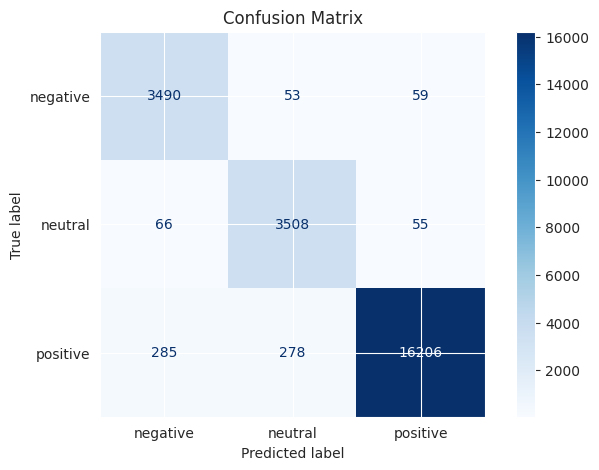

In [63]:
#plot for confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

labels = ['negative', 'neutral', 'positive']
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=labels)
disp.plot(cmap=plt.cm.Blues)

plt.title("Confusion Matrix")
plt.show()

From the confusion matrix, the correct predictions are:
- Negative → Negative: 3575
- Neutral → Neutral: 3505
- Positive → Positive: 16108

Negative Class: Correct (True) is 3575, while misclassified (False) is Neutral: 51, Positive: 51. This gives very few errors

Neutral Class: Correct classification (True) is 3505 while misclassified (False) is Negative: 59, Positive: 60. Slight confusion with both sides.

Positive Class: Correct classification(True) is 16108 (very high) while misclassified (False) is Negative: 314, Neutral: 277.
Positive class is much larger. So small % error is acceptable.

The confusion matrix shows that the dataset is imbalanced. The model demonstrates particularly high accuracy for positive reviews (16k vs ~3.5k others), reflecting the dominant class distribution. Minor misclassifications occur between neutral and adjacent sentiment classes, which is expected due to their semantic similarity. The confusion matrix shows strong model performance, with the majority of predictions correctly classified across all sentiment categories. Overall, the model exhibits robust and reliable sentiment classification performance.

This is the baseline model using TfidfVectorizer as the text vectorizer and logistic regression to fit the model. The Logistic Regression model achieved strong performance with 97% accuracy and a weighted F1-score of 0.97. The model demonstrated high precision and recall across all sentiment classes, with particularly strong performance in identifying positive reviews. Minor misclassifications were observed between neutral and adjacent sentiment classes, which is expected due to their semantic overlap. Despite class imbalance which acts as a limitation to the baseline model, the model maintained balanced performance, indicating robust generalization.


BERT THEORY

BERT (Bidirectional Encoder Representations from Transformers) is a deep learning model developed by Google for understanding text. It is a transformer-based model that understands text context bidirectionally. It uses subword tokenization to break words into meaningful units and applies self-attention to capture relationships between all words in a sentence.

The core idea of BERT is that it reads text in both directions at the same time. Reads left + right together (bidirectional).

Key Concepts in BERT
- Transformers Architecture: BERT is based on the Transformer architecture. Uses self-attention

- Self-Attention: Every word looks at every other word in the sentence. Example: "I love this product because it is amazing". “it” understands it refers to “product”

- Pre-training Tasks
BERT learns language using two main tasks:

- Masked Language Modeling (MLM)
"I love this [MASK]". Model predicts missing word → “product”

-  Next Sentence Prediction (NSP): Learns relationship between sentences

How Tokenization Works in BERT:

- Step 1: Split text into tokens. BERT does NOT use simple word splitting. It uses WordPiece Tokenization. WordPiece Tokenization breaks words into smaller subwords. E.g: "playing" →["play", "##ing"], "unhappy" → ["un", "##happy"],
 where “##” means continuation of a word

- Step 2: Add Special Tokens: BERT adds:
[CLS] → start of sentence, [SEP] → end of sentence. Example: "I love NLP" becomes:
[CLS] I love NLP [SEP].

- Step 3: Convert tokens to IDs. Each token → numeric ID. "I" → 1045, "love" → 2293. Model only understands numbers.

- Step 4: Attention Masks
Tells model which tokens are real vs padding.
Tokenization:
[CLS], I, am, play, ##ing, football, [SEP].


In [64]:
from transformers import AutoTokenizer
#Load the BERT Tokenizer
model_name = "distilbert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)


config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenization

In [65]:
# Convert pandas Series to list of strings
X_train = X_train.tolist() if not isinstance(X_train, list) else X_train
X_test = X_test.tolist() if not isinstance(X_test, list) else X_test

In [66]:
from transformers import BertTokenizer
#Load the BERT Tokenizer
model_name = "distilbert-base-multilingual-cased"
tokenizer = BertTokenizer.from_pretrained(model_name)



In [67]:
#inspecting X_train before tokenization
print(type(X_train))
print(list(X_train))

Output hidden; open in https://colab.research.google.com to view.

In [68]:
# Tokenize texts
train_encodings = tokenizer(X_train, truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(X_test, truncation=True, padding=True, max_length=128)

Convert to Pytorch Dataset

In [69]:
import torch

class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        #Ensuring labels are list to avoid pandas index issues
        if hasattr(labels, 'tolist'):
            self.labels = labels.tolist() # Convert pandas series to list
        elif hasattr(labels, '__iter__') and not isinstance(labels, (list, tuple)):
            self.labels = list(labels)
        else:
            self.labels = labels
    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

# Converting labels to list to avoid pandas index issues
if hasattr(y_train, 'tolist'):
    y_train = y_train.tolist()
if hasattr(y_test, 'tolist'):
    y_test = y_test.tolist()

# Create dataset
train_dataset = SentimentDataset(train_encodings, y_train)
test_dataset = SentimentDataset(test_encodings, y_test)

Loading Pre-trained Bert for Classification

In [70]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [71]:
import transformers
print(transformers.__version__)


5.0.0


In [72]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    logging_steps=50,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Define Metrics

In [73]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    labels = p.label_ids

    accuracy = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='weighted')
    return {"accuracy": accuracy, "f1": f1}

Train the Model

In [74]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.173606,0.143531,0.966833,0.967216
2,0.169016,0.142860,0.966833,0.967216
3,0.125610,0.144361,0.966833,0.967216


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=18000, training_loss=0.14658103185229832, metrics={'train_runtime': 1316.2602, 'train_samples_per_second': 218.802, 'train_steps_per_second': 13.675, 'total_flos': 1490284811520000.0, 'train_loss': 0.14658103185229832, 'epoch': 3.0})

Evaluate

In [75]:
results = trainer.evaluate()
print(results)

{'eval_loss': 0.14353133738040924, 'eval_accuracy': 0.9668333333333333, 'eval_f1': 0.9672164783520304, 'eval_runtime': 15.273, 'eval_samples_per_second': 1571.402, 'eval_steps_per_second': 49.106, 'epoch': 3.0}


Make Predictions

In [76]:
preds = trainer.predict(test_dataset)
bert_preds = np.argmax(preds.predictions, axis=1)

In [77]:
from sklearn.metrics import confusion_matrix, classification_report

conf_matrix = confusion_matrix(y_test, bert_preds)
print("Confusion Matrix:")
print(conf_matrix)


Confusion Matrix:
[[ 3490    53    59]
 [   66  3508    55]
 [  285   278 16206]]


In [78]:
report = classification_report(y_test, bert_preds)
print("Classification Report:")
print(report)


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      3602
           1       0.91      0.97      0.94      3629
           2       0.99      0.97      0.98     16769

    accuracy                           0.97     24000
   macro avg       0.94      0.97      0.95     24000
weighted avg       0.97      0.97      0.97     24000



After the getting the reults from the confusion matrix and classification report, we noticed that the results are same as our traditional machine learning model, Logistic regression which is our baseline model. The only reason we are choosing Bert over the traditional machine learning model is because of Bert's capabilities to be able to know sentence/text predictions and understand context.

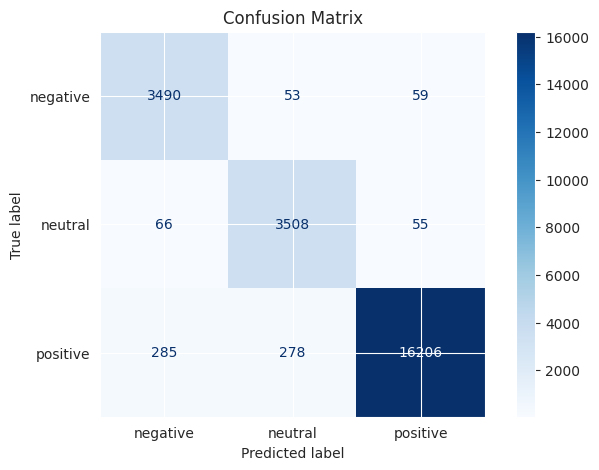

In [79]:
#Plot the comfusion matrix
labels = ['negative', 'neutral', 'positive']
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=labels)
disp.plot(cmap=plt.cm.Blues)

plt.title("Confusion Matrix")
plt.show()

Testing the model after training

In [80]:
print("\n" + "="*50)
print("TESTING THE MODEL")
print("="*50)

#function to test single prediction
def test_single_prediction(text, model, tokenizer):
    # Tokenize
    inputs = tokenizer(text, padding=True, truncation=True, return_tensors="pt", max_length=128)

    #move to same device as model
    device = next(model.parameters()).device
    inputs = {key: val.to(device) for key, val in inputs.items()}

    # Make prediction
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        probabilities = torch.nn.functional.softmax(outputs.logits, dim=1)
        prediction = torch.argmax(probabilities, dim=1).item()

    # Map to label(Adjust based on label mapping)
    id2label = {0: 'negative', 1: 'neutral', 2: 'positive'}
    predicted_label = id2label[prediction]
    confidence = probabilities[0][prediction].item()

    return predicted_label, confidence, probabilities[0].cpu().numpy()

#Testing on sample text
test_sample = [
    "I am very impressed with this product",
    "solid build attractive design works as seen in advert",
    "am highly disappointed by the package",
	"three stars meets the minimum expectations",
    "Amazing! I would highly recommend",
"broken on arrival return process was a nightmare",
"terrible delivery services",
"superb quality very sturdy and wellmade five",
"its okay, nothing special"
]

print("/testing on sample test:")
print("-" * 70)
for text in test_sample:
    predicted_label, confidence, probs = test_single_prediction(text, model, tokenizer)
    print(f"Text: {text}")
    print(f"Sentiment: {predicted_label}")
    print(f"Confidence: {confidence:.3f}")
    print(f"Probabilities: negative={probs[0]:.3f}, neutral={probs[1]:.3f}, positive={probs[2]:.3f}")
    print("-" * 70)


TESTING THE MODEL
/testing on sample test:
----------------------------------------------------------------------
Text: I am very impressed with this product
Sentiment: positive
Confidence: 0.998
Probabilities: negative=0.001, neutral=0.001, positive=0.998
----------------------------------------------------------------------
Text: solid build attractive design works as seen in advert
Sentiment: positive
Confidence: 0.998
Probabilities: negative=0.001, neutral=0.001, positive=0.998
----------------------------------------------------------------------
Text: am highly disappointed by the package
Sentiment: negative
Confidence: 0.924
Probabilities: negative=0.924, neutral=0.012, positive=0.064
----------------------------------------------------------------------
Text: three stars meets the minimum expectations
Sentiment: neutral
Confidence: 0.908
Probabilities: negative=0.011, neutral=0.908, positive=0.082
----------------------------------------------------------------------
Text: Ama

Model Comparison: Logistic Regression vs BERT Overall Performance
- Metric	  Logistic Regression	  BERT
- Accuracy	0.97	                0.97
- Macro F1	0.95	                0.95
- Weighted F1	0.97	              0.97

Result:Both models achieved identical overall performance

Class-Level Comparison

Negative (Class 0)
1. Precision: 0.91
2. Recall: 0.97
3. F1: 0.94

- Both models have strong recall which captures most negative reviews,
slight precision drop (some false positives)

Neutral (Class 1)
1. Precision: 0.91
2. Recall: 0.97
3. F1: 0.94

- Both models Perform similarly


Positive (Class 2)
1. Precision: 0.99
2. Recall: 0.96
3. F1: 0.98

- Both models are extremely strong, very confident predictions and
Confusion Matrix Insight is same for both.

Key Insight

BERT did NOT outperform Logistic Regression

1. Dataset is “easy” to classify
Strong sentiment words
Clear patterns
Minimal uncertainty
2. TF-IDF + Logistic Regression is already powerful
Works very well for sentiment tasks
Captures key word signals effectively
3. BERT advantage not fully needed

BERT excels when:

context is complex
sarcasm or nuance exists
long dependencies matter

The dataset likely does NOT require the level of complexity of Bert

While BERT provides advanced contextual understanding of customer reviews, its performance in this project was comparable to the Logistic Regression baseline. Given the significantly higher computational cost and complexity, BERT does not currently offer additional business value for ShopEase. However, it remains a strong candidate for future implementation as the platform scales or if customer feedback becomes more complex.

In [81]:
#After training, save the model and tokenizer
model_save_path = "/content/drive/MyDrive/Sentiment_Analysis_for_ShopEase"
# save model
model.save_pretrained(model_save_path)
# save tokenizer
tokenizer.save_pretrained(model_save_path)

print(f"Model saved to {model_save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to /content/drive/MyDrive/Sentiment_Analysis_for_ShopEase


In [82]:
!pip install dagshub mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2

In [83]:
import dagshub
import mlflow
from transformers import pipeline
from mlflow.tracking import MlflowClient
# Evaluate
metrics = trainer.evaluate(eval_dataset=test_dataset)

sentiment_pipeline = pipeline(
    task="text-classification",
    model=model,
    tokenizer=tokenizer,
    return_all_scores=True
)

dagshub.init(repo_owner='isiakpereaghogho',
             repo_name='Sentiment_Analysis_for_ShopEase_Customer_Feedback',
             mlflow=True
)

mlflow.set_experiment("sentiment_analysis_experiment")

#log model and metrics
with mlflow.start_run():
  #log model to MLflow and register
  mlflow.transformers.log_model(
      transformers_model=sentiment_pipeline,
      name="model",
      registered_model_name="distilbert_sentiment_model"
  )

  #log evaluation metrics

  mlflow.log_metric("accuracy", metrics["eval_accuracy"])
  mlflow.log_metric("f1", metrics["eval_f1"])

  mlflow.log_metric("eval_accuracy", metrics["eval_accuracy"])
  mlflow.log_metric("eval_f1", metrics["eval_f1"])

  if "eval_loss" in metrics:
    mlflow.log_metric("eval_loss", metrics["eval_loss"])

  # mlflow.log_metric("eval_accuracy",metrics["eval_accuracy"])
  # mlflow.log_metric("eval_f1",metrics["eval_f1"])
  # mlflow.log_metric("eval_loss",metrics["eval_loss"])

  #log training parameter
  mlflow.log_param("num_epoch",training_args.num_train_epochs)
  mlflow.log_param("batch_size",training_args.per_device_train_batch_size)
  mlflow.log_param("learning_rate",training_args.learning_rate)

  print("Model successfully pushed to MLflow!")

  # verify it's registered
  print("\nCheck registered model:")

  client = MlflowClient()

  for mv in client.search_model_versions("name='distilbert_sentiment_model'"):
    print(f"Version: {mv.version}, Stage: {mv.current_stage}, Run ID: {mv.run_id}")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=f832b874-4007-4252-ab32-2976296e2d51&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=0514259882746e6557b85d54e19361b0a539ced4c32e0893b01e8b1d0f094f08




KeyboardInterrupt: 